# Lab 1 Introduction to Jupyter Notebooks & FITS images

The Jupyter Notebook is an incredibly powerful tool for interactively developing and presenting data science projects. In this notebook, you will be introduced to Jupyter Notebook, learn the basics tools, open a FITS image and perform photometry. 

By the end of this lab, you should be able to: 
- Use the different cells types 
- Load in the appropriate python libraries need to complete your task
- Read in a FITS file and display the image in both ds9 & in a Jupyter Notebook 
- Understand the structure of the lab and the marking rubric



## In a notebook, there are two types of cells:
- A **code cell** which contains code to be executed in the kernel and displays its output below.
- A **Markdown cell** which contains text formatted using Markdown and displays its output in-place when it is run

## Markdown Cells
Cell one and two in this notebook are Markdown cells. You will use Markdown cells to take notes, answer questions and write observations and conclusions, so it is important that you are comfortable with using Markdown cells by the end of this lab. You can "code" your Markdown cell to bold text, use different colours and write equations similar to LaTeX. Once you are done writing out a Markdown cell, you run it by clicking the Run button on the Menu bar or using the keyboard short-cut "shift+enter."

### Below are a few basic tasks to help you become comfortable with running cells, adding cells and editing markdown. 

**Task 1.** Try running the first code cell in this notebook. (If you encounter an error message, did you activate the obsastro environment before opening this notebook.)

**Task 2.** Add a Markdown cell below. You can do this by adding a new cell (+ icon) and then changing the type to Markdown or using a keyboard shortcut. In this cell introduce yourself to the TAs. Please mention your major, why did you choose to take this unit, what you hope to learn in the unit, any fun facts you want to tell us and <font color=red>(most importantly)</font> your favorite cookie. In this Markdown cell, you need make sure, you use:
- two types of headings
- <font color=green>different colours.</font> <font color=blue>Do not use black for your responses (**for everything**). It helps the TAs distinguish your responses. </font>
- *either bold or italic font*

Here's some resources on why you should Python: https://medium.com/@mindfiresolutions.usa/python-7-important-reasons-why-you-should-use-python-5801a98a0d0b and a markdown cell shortcut cheatsheet: https://medium.com/ibm-data-science-experience/markdown-for-jupyter-notebooks-cheatsheet-386c05aeebed.



### <font color=red>Task 1</font>

Hello, my name is *Alec Stanley*. My science major is Astrophysics, which I am doing in a double degree with Aerospace Engineering. The obvious reason I took this unit is because it's required for my major, but the wider reason I am interested in this field is my lifelong love of space. I have never enjoyed learning as much as when I am studying my astrophysics units.

### <font color=green>Favourite cookie
**Chocolate chip (white choc macadamia is a close second)**

# Code Cells

Code Cells basically allows you to enter and run code. You can import libraries, write functions and objects, plot data, etc. Throughout this unit, we will use code cells to process, reduce and visualize FITS images. We will provide a **(short)** pre-lab coding practice problems as well as science questions each week and extra resources so by the end of the semester you will be comfortable with coding and Jupyter Notebook

## Let begin this weeks notebook:
**Task 3.** As a first step, we need to import the python libraries that are critical for today's workshop, including numpy (numerical), astropy (astronomy), ccdproc (CCD) and matplotlib (plotting). Click on the cell below and then click the run button above. (Don't forget to run cell too if you haven't).

In [1]:
import numpy as np                     # This is an example of a comment
import astropy                         # This is importing astropy
import ccdproc                         # What is this doing?
from ccdproc import CCDData, combiner  # What is this doing?
from astropy import units as u         # You should get into the habit of commenting code
import matplotlib.pyplot as plt        # Importing matplotlib.pyplot as plt is quite common

# Python Libraries: 
One of the many reasons why we are using python is the amount of documentation and help guides that are available via a basic google search. **You should very careful about what site you use** but you can find a tutorial or a guide for just about anything you are trying to do.

**Task 4.** As you see above, we used different import statements. What does each different import statement mean/do? In particular, how does *import [library]* diff from *import [library] as [shortname]*?

**Task 5.** In a new Markdown box, write <font color=red>point form</font> descriptions about the libraries we are importing. 



### <font color=red>Task 4 and 5</font>
"import" tells your program to reference another library, allows use of other functions
"import library_name as short_hand" tells your program to let you use the shorthand name as an alias. For example, numpy.sqrt() becomes np.sqrt() if I did import numpy as np.

* **numpy**, short for numerical python, is an essential, open-source Python library used for scientific and numerical computing.
* **astropy** is another python library specifically for data analysis for astrophysics and astronomy.
* **ccdproc** is a library for processing CCD images, affiliated with astropy. 'from (library) import (function1), (function2), etc' means to **only** import specific functions from the library, instead of the whole library. By being explicit this helps with simplicity and readability. For example if I do 'import numpy as np' I can then do np.sqrt(). However, if I do 'from numpy import sqrt', I can then just use sqrt() directly in the namespace.
You can extend this with aliases, like the next line 'from astropy import units as u' which lets me use the 'units' function from astropy using the alias 'u', for example 'u.mass_energy()'.
* **matplotlib** is a complete plotting library for python, making static and animated visualisations.

**Task 6.** Lets now load an example FITS image from the Monash C14 telescope, NGC_2362_V_30.000secs00010838.fit.

In [2]:
image_1 = CCDData.read("NGC_2362_V_5.000secs00009644.fit", unit="adu")

**Task 7.** Lets now print some example pixel values from this image. Display this image with ds9 too, and compare the individual pixel values (starting at the corners of the image). Record your observations in a new Markdown cell. For example, which pixel values correspond to which corner of the image you loaded into ds9.

In [3]:
print(image_1.data)


[[ 999 1031 1039 ... 1041 1001 1033]
 [1066 1068 1035 ...  983 1005 1043]
 [1065 1062 1091 ... 1047 1002 1040]
 ...
 [1052 1019 1025 ... 1033 1024 1062]
 [1077 1077 1098 ... 1022 1052 1042]
 [1074 1046 1079 ... 1078 1047 1005]]


### <font color=red>Task 7</font>
By hovering over pixels in ds9, I have discovered that the Python data table lists the data row-by-row, starting from the bottom left-most pixel. The next row starts at the left again. The pixel value represents the 'brightness' or 'flux' that is displayed on ds9.

**Task 8.** Lets print just one specific pixel value. Where is this pixel value in the image that is displayed with ds9?

In [4]:
print(image_1.data[0,0]) 

999


### <font color=red> Task 8</font>
Bottom-left pixel

**Task 9.** Lets print a specific row. Confirm where this row is in your image using ds9. (Hint, this was done in a video.)

In [5]:
print(image_1.data[0,:])

[ 999 1031 1039 ... 1041 1001 1033]


### <font color=red> Task 9</font>
Bottom row, left to right

**Task 10.** Lets print a specific column. Confirm where this column is in your image using ds9.

In [6]:
print(image_1.data[:,0])

[ 999 1066 1065 ... 1052 1077 1074]


### <font color=red> Task 10</font>
Left-most column, bottom to top

**Task 11.** How would you print a pixel value (or values) at the location of the bright star near the centre of the image? Use ds9 to assist you and then write the relevant command below in a code cell and run it. 

### <font color=red> Task 11</font>
To do this, I would first go to ds9 and mouse-hover over the central star. The x and y values will tell me what entries to print in Python, recalling the left-right, bottom-top convention. To print a range, I can print out a region of data using Python's list indexing with the x and y values I get from ds9.

In [7]:
# ds9 Coordinates
x_coord = 1718
y_coord = 1276

# Index by row, then column. Should be a high value
print(image_1.data[y_coord-1, x_coord-1])

65535


**Task 12.** We can now use numpy (np) to determine some of the basic statistics (min, max, mean, median) of the image and print them to the screen.

In [8]:
print('Min:', np.min(image_1.data))


Min: 577


**Task 13.** 
How would you determine the mean and standard deviation of the image? There are online resources that can help you determine which functions to use.

### <font color=red>Task 13</font>
np.mean(), np.std() are the functions I would use. See next cell.

In [9]:
print(f'Mean: {np.mean(image_1.data):.4f}')
print(f'StD: {np.std(image_1.data):.4f}')

Mean: 1031.0610
StD: 331.6505


# Reminder: are you keeping notes as you work through this notebook? For each Task, you should have written notes/ observations in a new markdown cell.

**Task 14.** Lets now display the image using matplotlib and compare what we see with ds9. Describe how the images differ from each other (and, where possible, why they differ).

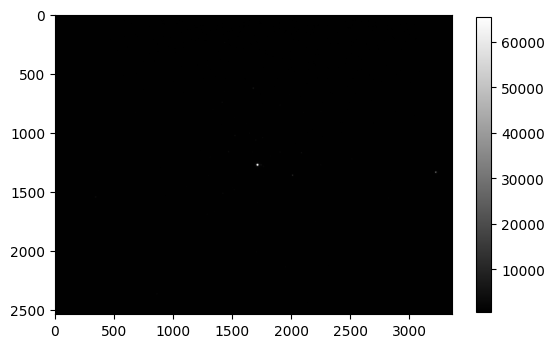

In [10]:
plt.imshow(image_1.data, cmap='gray')
plt.colorbar(shrink=0.8)

### <font color=red>Task 14</font>
They pretty much look the same. In the default min/max scale on ds9, you can pretty much only see the small faint white star in the middle.

### What we see does depend on the colour range that we have selected. In ds9, we can change the colour range by editting the min and max values until we are happy with the images. We can do the same here.

**Task 15.** Lets now try a different colour scales, so we can see more stars in the image. We can alter the pixel values that correspond to black and white in the display, and we can try a log scaling instead of linear scaling. For log scaling we do need to import from matplotlib.colors. How do the different displays of the images compare? Have the pixel values in the image actually changed? 

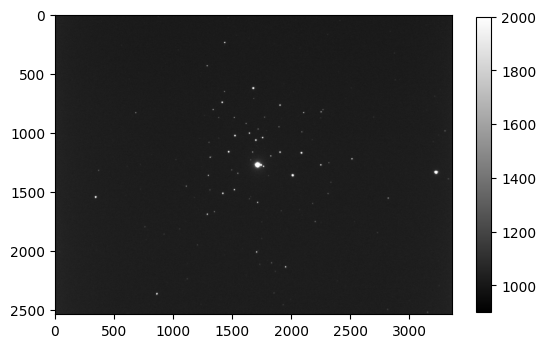

In [11]:
plt.imshow(image_1.data, cmap='gray', vmin=900, vmax=2000)
plt.colorbar(shrink=0.8)

In [12]:
from matplotlib.colors import LogNorm

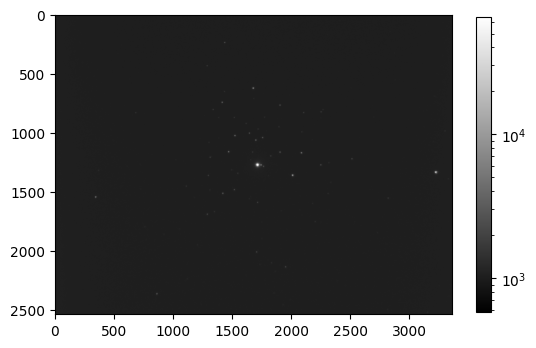

In [13]:
plt.imshow(image_1.data, cmap='gray', norm=LogNorm())
plt.colorbar(shrink=0.8)

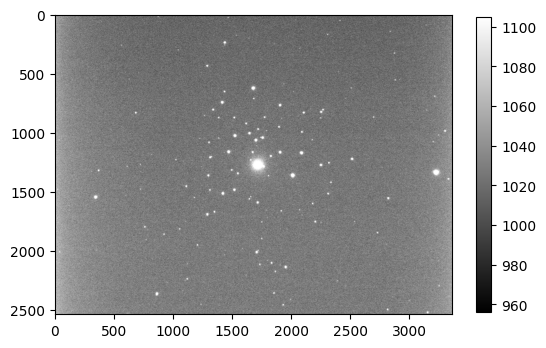

In [14]:
# What is the following code doing?

vmin=np.percentile(image_1.data,1)        # vmin represents the highest value of the bottom one percent of the data
vmax=np.percentile(image_1.data,99)       # vmax represents the lowest value of the top one percent of the data
plt.imshow(image_1.data, cmap='gray', vmin=vmin, vmax=vmax)  # By calculating our vmin and vmax dynamically based on the input data, we are essentially 'cutting out' the 1% lowest and 1% highest values. There is a lot of darkness, so this would help a lot
plt.colorbar(shrink=0.8)

### <font color=red>Task 15</font>
In the first image we see some scaling. It makes the less bright stars much easier to see. It is also now obvious that the y-axis is flipped.
In the next image we are using logarithmic scaling. This makes the image more clear than the original, but less clear than the scaled min/max one earlier. The final image is the clearest. The code calculates the values of the lowest and highest 1% of the data and uses them to omit that data. The result is an image with has the darkest and brightest values cut out, making the stars extremely obvious. It is important to know that the actual pixel values in each image have not changed, just the display scale. Therefore any calculations involving light flux will work the same.

**Task 16.** How can we modify the orientation of the image so the origin is at the lower left? How do we add axes labels and a title? Feel free to use online resources to determine how to do this. What keywords did you use to find resources?

Text(0.5, 1.0, 'CCD Data of NGC 2362')

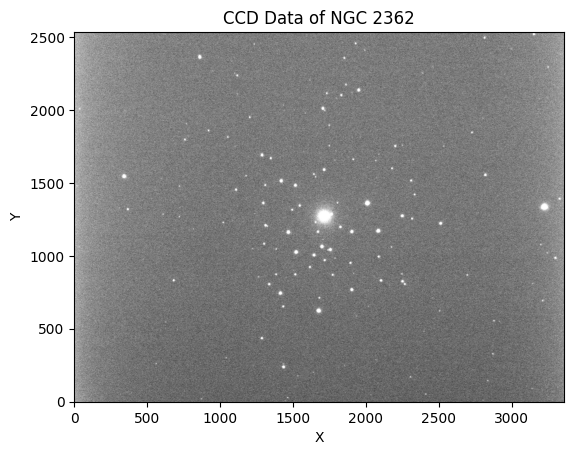

In [15]:
# Setting origin='lower' will set the origin at the lower value. Michael helped me with this.
plt.imshow(image_1.data, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
# Here is the labeling. I did not need to look this up
plt.xlabel("X")
plt.ylabel("Y")
plt.title("CCD Data of NGC 2362")

### Looking at images of stars is nice, but we want to quantify the properties of those stars. 

**Task 17.** To do this, lets undertake photometry using the photutils libraries. Write a <font color=red>point form</font> descriptions of each of the modules we are importing in.

In [16]:
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground

### <font color=red>Task 17</font>
PhotUtils is a python library affiliated with Astropy designed for performing photometry.
* CircularAperture defines circular regions (with a centre and radius) to measure total flux from sources within that circle. It supports partial pixel weighting.
* aperture_photometry is a toolbox for summing the flux within the given aperture. You'd use this in conjunction with the CircularAperture function.
* Background2D estimates a background map in a given image. It works by interpolating a low resolution background map.
* MedianBackground calculates the background based on a median value, used with the above function.
This information was found on https://photutils.readthedocs.io/ (Official documentation)

If we are to measure photometry, we need to make sure we subtract off the photons (electrons) coming from the background sky rather than celestial sources.

**Task 18.** We can create a background image using Background2D. What is Background2D doing? Take a look at
https://photutils.readthedocs.io/en/stable/api/photutils.background.Background2D.html#photutils.background.Background2D to find out. What are the roles of each of the parameters that we have defined?

In [17]:
bkg = Background2D(image_1.data, box_size=100, bkg_estimator = MedianBackground() )

### <font color=red>Task 18</font>
We are calling the Background2D function using the MedianBackground() estimator, which calculates the background based on median values. The first parameter is passing in our image CCD data. The box_size parameter defines a box, in this case 100x100. This means the function will split the image up into a grid of 100x100 boxes, calculating the background based off the median in each of these boxes.

**Task 19.** Lets now do print(bkg) and see what comes out.

In [18]:
print(bkg)

<photutils.background.background_2d.Background2D>
data: '<array; shape=(2536, 3358)>'
box_size: array([100, 100])
mask: None
coverage_mask: None
fill_value: 0.0
exclude_percentile: 10.0
filter_size: array([3, 3])
filter_threshold: None
edge_method: 'pad'
sigma_clip: SigmaClip(sigma=3.0, sigma_lower=3.0, sigma_upper=3.0, maxiters=10, cenfunc='median', stdfunc='std', grow=False)
bkg_estimator: MedianBackground(sigma_clip=None)
bkgrms_estimator: StdBackgroundRMS(sigma_clip=None)
interpolator: BkgZoomInterpolator(order=3, mode='reflect', cval=0.0, clip=True, grid_mode=True)


**Task 20.** Lets now print the attributes of the bkg class.

In [19]:
print(dir(bkg))

['_Background2D__repr_str_params', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply_units', '_bkg_stats', '_bkgrms_stats', '_box_npixels', '_calculate_image', '_calculate_mesh_yxcen', '_calculate_stats', '_combine_all_masks', '_combine_input_masks', '_compute_box_statistics', '_data_dtype', '_data_shape', '_filter_grid', '_good_npixels_threshold', '_interp_kwargs', '_interpolate_grid', '_mask', '_mesh_nan_mask', '_min_bkg_stats', '_ngood', '_selective_filter', '_sigmaclip_boxes', '_unit', '_validate_array', 'background', 'background_median', 'background_mesh', 'background_mesh_masked', 'background_rms', 'background_rms_median', 'background_rms_mesh', 'background_rms_mesh_m

**Task 21.**  Lets now look at the value of one of these attributes. What information is this attribute outputting? 

In [20]:
print(bkg.background_median)


1027.0


### <font color=red>Task 21</font>
This is the median pixel value of the background.

**Task 22.** Now lets take a look at the background image. 

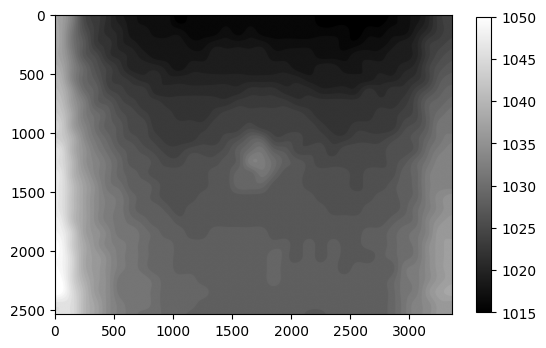

In [21]:
plt.imshow(bkg.background, cmap='gray')
plt.colorbar(shrink=0.8)

**Task 23.** Below are the commands that undertake aperture photometry of two stars. Can you describe what each line does, and what the relevant inputs are? 

In [22]:
positions = [(1713.0, 1274.0), (3220.0, 1337.0)]
apertures = CircularAperture(positions, r=20.0)
phot_table = aperture_photometry(image_1.data-bkg.background, apertures)

### <font color=red>Task 23</font>
* Line 1: Defines a short list of the target coordinates we want to form apertures around
* Line 2: Calls the CircularAperture function to define circles of 20px radius around the target positions
* Line 3: Calls the aperture_photometry function, passing in the **raw CCD data minus the background**, filtering by our apertures. The result will be a table of summation values, one for each aperture.

**Task 24.** We can now print the photometry to the screen.

In [23]:
print(phot_table)

 id xcenter ycenter    aperture_sum   
--- ------- ------- ------------------
  1  1713.0  1274.0 17778976.951494135
  2  3220.0  1337.0  4261151.051529652


**Task 25.** Now undertake aperture photometry of four stars with an aperture radius of 15 pixels. 

### <font color=red>Task 25</font>

In [24]:
positions = [(1713.0, 1274.0), (3220.0, 1337.0), (2011, 1364), (2086, 1172)]
apertures = CircularAperture(positions, r=15.0)
phot_table = aperture_photometry(image_1.data-bkg.background, apertures)
print(phot_table)

 id xcenter ycenter    aperture_sum   
--- ------- ------- ------------------
  1  1713.0  1274.0 16956970.739505883
  2  3220.0  1337.0  4052199.911017647
  3  2011.0  1364.0   1301625.28602127
  4  2086.0  1172.0 1608928.8696237118


# <font color=red>Conclusion</font>
This task taught me how to perform aperture photometry in Python, which will be useful for the project component of this unit. I previously only knew how to do this using the built-in features and tabs in ds9, but now I have more control over this process and know how it works in greater detail.

# Lab Conclusion:

You have now completed the "coding" part of the lab. Before you submit your notebook to be marked, here is a quick checklist you should go through to ensure you have fully completed the lab and achieved the learning goals stated in the first cell of the lab.

    1. Did I write a conclusion?
    
    2. Did I complete all the **Tasks**? Tasks will be a mix of running code, answering questions and writing your own code. Be careful to go through them and double-check you have answered all the questions. You should also comment/ write down notes about the code and the task it is performing. **Please make sure your responses are in different colours**
    
    3. Does my Jupyter notebook run? The TAs will open each notebook and press "run all" to check if your notebook works perfectly, so a good test is to run your notebook as a whole once you have completed the lab. To do this, go to *Kernel* and press *Restart and run all*
    
    4. Do I understand every bit of this Notebook? Each lab, we will be building upon what we did in the previous week and will not have time to backtrack on the material, so it is very important that you understand the material that we covered before the next lab. That includes the science contents, telescope data processing methods and the coding concepts we have covered. If you have questions (after you have reviewed the lab and your class notes), you can either post on the Moodle Discussion Forum or list them after your conclusion and the TA will address. 


# Pre-Lab Questions:

The following labs and their jupyter notebook will have pre-lab questions that you will need to complete and sumbit (via Moodle) in your notebook before your lab session (e.g. before Friday 11am). 

The pre-lab questions will be a mixture of short coding exercises and conceptal questions. The purpose of the pre-labs are provide background for that week's lab and hand-on practice with python, so you can preform well in lab. It is very important that you complete each pre-lab, as it will also contribute to your lab mark for that week. 